In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

%matplotlib inline 

pd.set_option('display.max_columns', None)

In [14]:

FILE_PATH = "data/confidence_features.csv" 
try:
    df = pd.read_csv(FILE_PATH)
except FileNotFoundError:

    FILE_PATH = "confidence_features.csv" 
    df = pd.read_csv(FILE_PATH)


print("veri seti ilk 5 gozlem:")
display(df.head())

print("\nveri tipi ve eksik deger bilgisi:")
df.info()

print("\nhedef sinif dagilimi:")
print(df['confidence_label'].value_counts())

veri seti ilk 5 gozlem:


,eye_shoulder_y_ratio,shoulder_y_diff,wrist_distance_x,wrist_shoulder_ratio,nose_eye_center_offset_x,shoulder_span,hip_shoulder_y_diff,body_lean_x,shoulder_center_x,hip_center_x,spine_angle,eye_distance,head_tilt_angle,eye_distance_ratio,shoulder_slope,head_direction,arm_position,posture,confidence_label
0,-0.503596,0.007476,0.579019,1.265216,0.005173,0.457695,0.940374,-0.013120,0.528733,0.541853,89.200695,0.145957,-9.428943,0.318896,0.007476,Looking Straight,Partially Open,Upright,Confident
1,-0.483258,0.008997,0.569416,1.252966,0.005959,0.454533,0.956052,-0.011132,0.530794,0.541926,89.332889,0.149509,-8.837170,0.328929,0.008997,Looking Straight,Partially Open,Upright,Confident
2,-0.499847,0.007365,0.565545,1.241425,0.004157,0.455611,0.957542,-0.009751,0.531381,0.541132,89.416540,0.149602,-8.891050,0.328355,0.007365,Looking Straight,Partially Open,Upright,Confident
3,-0.507275,0.004634,0.567566,1.241538,0.004660,0.457161,0.960712,-0.007606,0.532167,0.539773,89.546409,0.149433,-8.448227,0.326873,0.004634,Looking Straight,Partially Open,Upright,Confident
4,-0.531431,0.003360,0.568783,1.243352,0.006326,0.457462,0.978154,-0.006108,0.532303,0.538410,89.642240,0.152196,-9.405679,0.332696,0.003360,Looking Straight,Partially Open,Upright,Confident



veri tipi ve eksik deger bilgisi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5949 entries, 0 to 5948
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   eye_shoulder_y_ratio      5949 non-null   float64
 1   shoulder_y_diff           5949 non-null   float64
 2   wrist_distance_x          5949 non-null   float64
 3   wrist_shoulder_ratio      5949 non-null   float64
 4   nose_eye_center_offset_x  5949 non-null   float64
 5   shoulder_span             5949 non-null   float64
 6   hip_shoulder_y_diff       5949 non-null   float64
 7   body_lean_x               5949 non-null   float64
 8   shoulder_center_x         5949 non-null   float64
 9   hip_center_x              5949 non-null   float64
 10  spine_angle               5949 non-null   float64
 11  eye_distance              5949 non-null   float64
 12  head_tilt_angle           5949 non-null   float64
 13  eye_distance_ratio        59

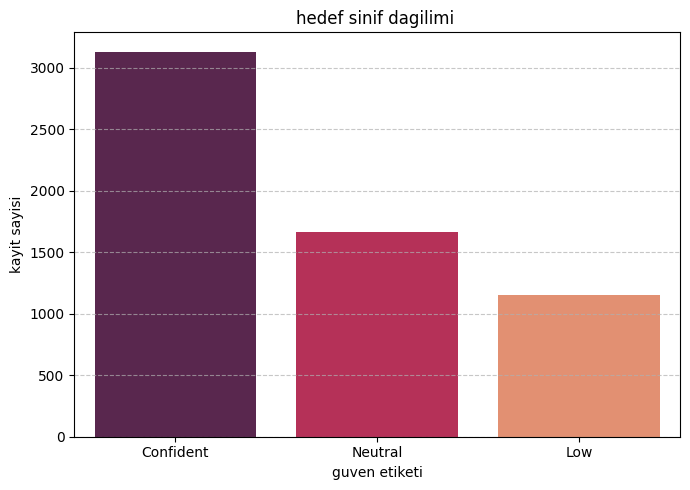

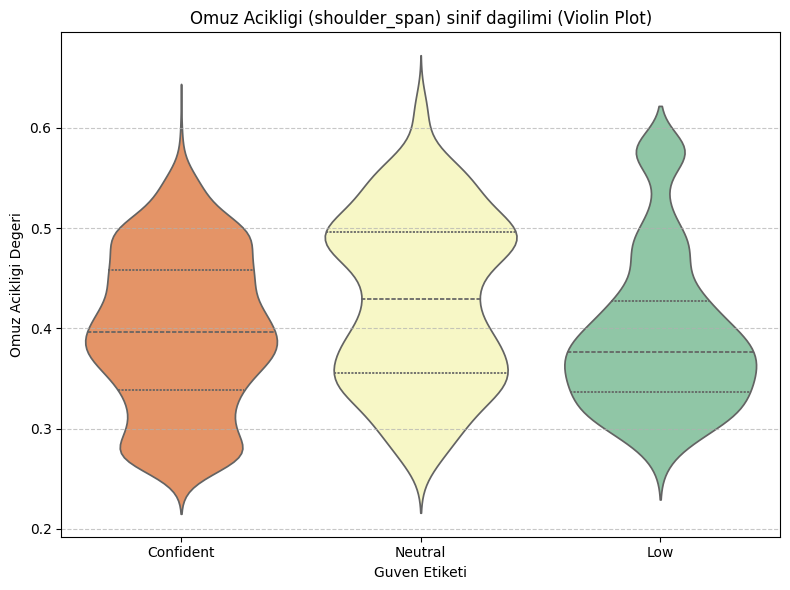

In [13]:

## kesifci veri analizi (EDA) försellestirmes


# sadece kod blogunu degiştirin

## hedef sinif dagilimi 
plt.figure(figsize=(7, 5))
sns.countplot(x='confidence_label', data=df, palette='rocket',
              # UYARI
              hue='confidence_label', legend=False, 
              order=df['confidence_label'].value_counts().index)
plt.title('hedef sinif dagilimi ')
plt.xlabel('guven etiketi')
plt.ylabel('kayit sayisi')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show() 

## kritik ozellik dagilimi (Violin Plot )

plt.figure(figsize=(8, 6))
sns.violinplot(x='confidence_label', y='shoulder_span', data=df, palette='Spectral',
               # UYARI SATIRI
               hue='confidence_label', legend=False, 
               order=df['confidence_label'].value_counts().index, inner='quartile')
plt.title('Omuz Acikligi (shoulder_span) sinif dagilimi (Violin Plot)')
plt.xlabel('Guven Etiketi')
plt.ylabel('Omuz Acikligi Degeri')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Pair Plot olusturuluyor...


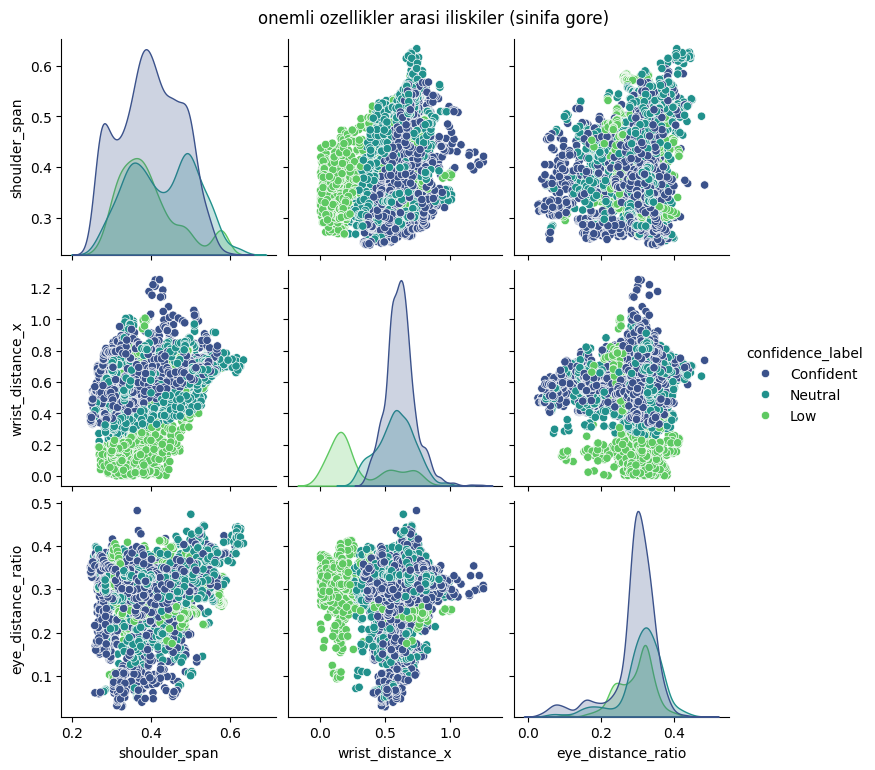

In [16]:
## onemli ozellikler arasi iliskiler (Pair Plot)
# Modelin onem verecegi en iyi 3 surekli ozellik ve hedef degiskeni seciyor

features_for_pairplot = ['shoulder_span', 'wrist_distance_x', 'eye_distance_ratio', 'confidence_label']
df_subset = df[features_for_pairplot]

print("Pair Plot olusturuluyor...")
g = sns.pairplot(df_subset, hue='confidence_label', palette='viridis', diag_kind='kde')
g.fig.suptitle("onemli ozellikler arasi iliskiler (sinifa gore)", y=1.02)
plt.show()

In [17]:
## veri on isleme 
# kategorik kolonlari yakalama
categorical_cols = ["head_direction", "arm_position", "posture"]

# One-Hot Encoding

df = pd.get_dummies(df, columns=categorical_cols)

# Label Encoding (hedef degisken)

label_encoder = LabelEncoder()
df["confidence_label_encoded"] = label_encoder.fit_transform(df["confidence_label"])

# x ve y  ayirma
X = df.drop(["confidence_label", "confidence_label_encoded"], axis=1)
y = df["confidence_label_encoded"]

# egitme ve test setlerine ayirma (%80 egitim / %20 Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"egitim seti boyutu: {X_train.shape}")
print(f"test seti boyutu: {X_test.shape}")

egitim seti boyutu: (4759, 25)
test seti boyutu: (1190, 25)


In [18]:
## model olusturma ve egitme

# Model Secimi: Random Forest Classifier 
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print("Random Forest Modeli basariyla egitildi.")

Random Forest Modeli basariyla egitildi.


Model Dogrulugu (accuracy): 0.9756 (97.56%)


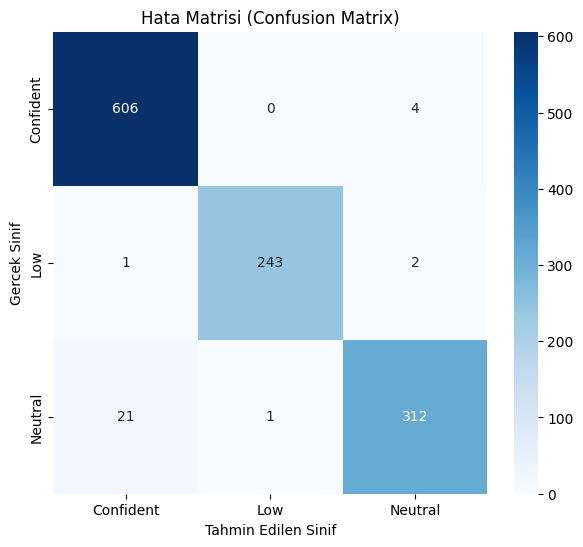

In [19]:
## model degerlendirme
y_pred = model.predict(X_test)

# dogruluk skoru (accuracy)
acc = accuracy_score(y_test, y_pred)
print(f"Model Dogrulugu (accuracy): {acc:.4f} ({acc*100:.2f}%)")

# hata matrisi (Confusion Matrix)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Hata Matrisi (Confusion Matrix)")
plt.xlabel("Tahmin Edilen Sinif")
plt.ylabel("Gercek Sinif")
plt.show() # Grafigi notebook'ta gosteriyoruz.

C:\Users\erenb\AppData\Local\Temp\ipykernel_22964\3187618593.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_features.values, y=top_10_features.index, palette="viridis")


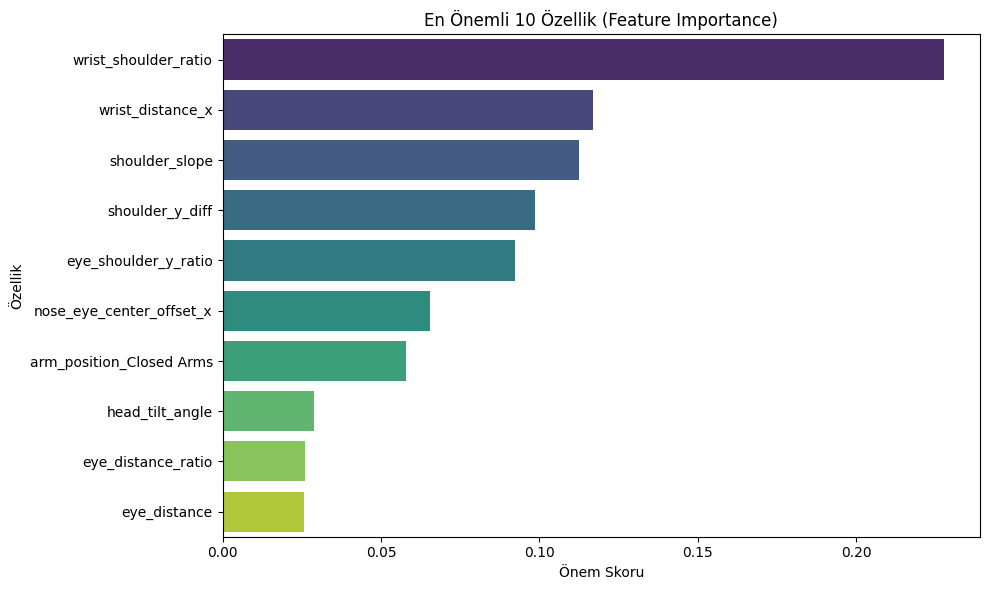

In [8]:
## Özellik Önem Sıralaması (Feature Importance)
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
top_10_features = feature_importances.nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette="viridis")
plt.title("En Önemli 10 Özellik (Feature Importance)")
plt.xlabel("Önem Skoru")
plt.ylabel("Özellik")
plt.tight_layout()
plt.show() # Grafiği notebook'ta gösteriyoruz.

In [20]:
## ornek tahmin fonksiyonu 

def predict_confidence(sample_dict):
    
    
    temp = pd.DataFrame([sample_dict])
    
    temp = pd.get_dummies(temp)

    for col in X.columns:
        if col not in temp.columns:
            temp[col] = 0

    temp = temp[X.columns]
    
    # Tahmin
    prediction = model.predict(temp)
    
    # Tahmini etikete cevirir
    predicted_label = label_encoder.inverse_transform(prediction)
    return predicted_label[0]

# ornek tahmin icin tum ozellikler gereklidir
sample = {
    "eye_shoulder_y_ratio": -0.49,
    "shoulder_y_diff": 0.006,
    "wrist_distance_x": 0.57,
    "wrist_shoulder_ratio": 1.24,
    "nose_eye_center_offset_x": 0.005,
    "shoulder_span": 0.45,
    "hip_shoulder_y_diff": 0.95,
    "body_lean_x": -0.01,
    "shoulder_center_x": 0.53,
    "hip_center_x": 0.54,
    "spine_angle": 89.0,
    "eye_distance": 0.14,
    "head_tilt_angle": -9.0,
    "eye_distance_ratio": 0.32,
    "shoulder_slope": 0.007,
    "head_direction": "Looking Straight",
    "arm_position": "Partially Open",
    "posture": "Upright"
}

result = predict_confidence(sample)
print(f"\nornek gozlem icin tahmin edilen guven seviyesi: {result}")


ornek gozlem icin tahmin edilen guven seviyesi: Confident
